# IE 164 Final Project: **RouteMind AI**
by I Gy Chen

## Environment Setup

In [144]:
import sys

if 'google.colab' in sys.modules:
    %pip install pyomo >/dev/null 2>/dev/null
    %pip install highspy >/dev/null 2>/dev/null

import pyomo.environ as pyo
assert pyo.SolverFactory('appsi_highs').available(), "HiGHS not found — run: pip install highspy"

In [145]:
# Package
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

In [146]:
# Configuration

CSV_PATH = "routerbench.csv"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

ALPHA_GRID = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
ALPHA_FIXED = 1.0
K_GRID      = list(range(1, 13))
BUDGET_GRID = [5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2]

WEIGHT_SCHEMES = {
    'Uniform':         None,
    'Coding-Heavy':    ['LCB'],
    'Math-Heavy':      ['AIME'],
    'Knowledge-Heavy': ['GPQA', 'MMLU-Pro'],
}

In [147]:
# Utility functions

def choose_solver():
    candidate_solvers = ["appsi_highs"]
    for name in candidate_solvers:
        try:
            solver = pyo.SolverFactory(name)
            if solver is not None and solver.available(False):
                print(f"Using solver: {name}")
                return solver
        except Exception:
            pass
    raise RuntimeError(
        "No MILP solver found. Install HiGHS via `pip install highspy`, "
        "or install CBC/GLPK and make sure it is available to Pyomo."
    )

def safe_float(x, default=0.0):
    try:
        if pd.isna(x):
            return default
        return float(x)
    except Exception:
        return default

# Data loading, Preprocessing, EDA

In [148]:
# Data loading, Preprocessing

def load_routerbench_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    required_cols = ["dataset", "prompt_id", "model", "score", "cost"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"CSV is missing required columns: {missing}")

    # Normalize types
    df['dataset']   = df['dataset'].astype(str)
    df['prompt_id'] = df['prompt_id'].astype(str)
    df['model']     = df['model'].astype(str)
    df['score']     = pd.to_numeric(df['score'], errors='coerce').fillna(0.0)
    df['cost']      = pd.to_numeric(df['cost'],  errors='coerce').fillna(0.0)
    
    # Keep one row per (prompt_id, model)
    dupes = df.duplicated(subset=["prompt_id", "model"])
    if dupes.any():
        print(
            f"Warning: found {dupes.sum()} duplicated (prompt_id, model) rows. "
            "Keeping the first occurrence."
        )
        df = df.drop_duplicates(subset=["prompt_id", "model"], keep="first").copy()

    return df

def make_parameter_dicts(df: pd.DataFrame):
    score = {}
    cost = {}
    dataset_of_prompt = {}

    for _, row in df.iterrows():
        p = row["prompt_id"]
        m = row["model"]
        d = row["dataset"]
        score[(p, m)] = safe_float(row["score"], 0.0)
        cost[(p, m)] = safe_float(row["cost"], 0.0)
        dataset_of_prompt[p] = d

    prompts = sorted(df["prompt_id"].unique().tolist())
    models = sorted(df["model"].unique().tolist())
    datasets = sorted(df["dataset"].unique().tolist())

    return prompts, models, datasets, score, cost, dataset_of_prompt


def build_prompt_weights(df, focus_datasets=None, boost=3.0):
    prompt_dataset = (df[['prompt_id', 'dataset']].drop_duplicates().set_index('prompt_id')['dataset'].to_dict())
    prompts = sorted(prompt_dataset.keys())
    
    if focus_datasets is None:
        return {p: 1.0 / len(prompts) for p in prompts}
    
    raw = {p: (boost if prompt_dataset[p] in focus_datasets else 1.0) for p in prompts}
    total = sum(raw.values())
    return {p: raw[p]/total for p in prompts}


In [149]:
# Data Summary

df = load_routerbench_data(CSV_PATH)

print(f'Rows: {len(df):,}, Prompts: {df.prompt_id.nunique()}, Models: {df.model.nunique()}')
print()
print('Prompts per benchmark:')
print(df[['prompt_id', 'dataset']].drop_duplicates()['dataset'].value_counts().sort_index())

summary = df.groupby('model').agg(avg_score=('score', 'mean'), avg_cost=('cost', 'mean'), max_cost=('cost', 'max'))
summary['free'] = summary['max_cost'] == 0
print()
print('Model Performance Summary:')
print(summary[['avg_score', 'avg_cost', 'free']].sort_values('avg_score', ascending=False).to_string())

free_list = summary[summary['free']].index.tolist()
print(f'\nFree models ({len(free_list)}): {free_list}')


Rows: 7,860, Prompts: 240, Models: 33

Prompts per benchmark:
dataset
AIME        60
GPQA        60
LCB         60
MMLU-Pro    60
Name: count, dtype: int64

Model Performance Summary:
                                 avg_score  avg_cost   free
model                                                      
gpt-5                             0.887500  0.042548  False
qwen3-235b-a22b-thinking-2507     0.845833  0.014699  False
deepseek-r1-0528                  0.841667  0.021899  False
gemini-2.5-pro                    0.829167  0.108404  False
gpt-5-chat                        0.741667  0.004704  False
kimi-k2-0905                      0.737500  0.004329  False
glm-4.6                           0.737500  0.019497  False
qwen3-235b-a22b-2507              0.729167  0.001756  False
deepseek-v3.1-terminus            0.705556  0.001615  False
gemini-2.5-flash                  0.700000  0.015802  False
Qwen3-8B                          0.670833  0.001339  False
DeepSeek-R1-0528-Qwen3-8B         0.

Prompts where all models agree (std=0): 4 / 240
Mean cross-model std per prompt: 0.444
Cost–score correlation: 0.476


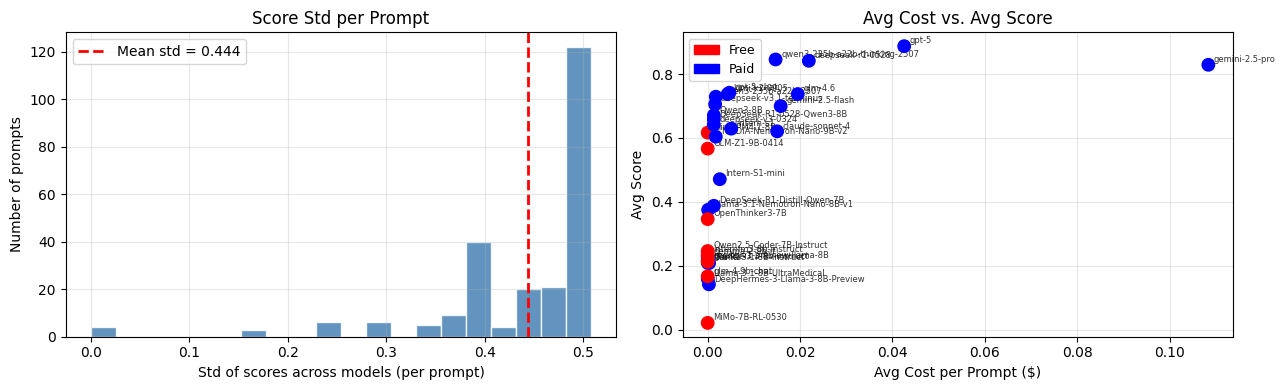

Saved eda_disagreement.png


In [150]:
from matplotlib.patches import Patch

prompt_std = df.groupby('prompt_id')['score'].std()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(prompt_std, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(prompt_std.mean(), color='red', lw=2, ls='--',
           label=f'Mean std = {prompt_std.mean():.3f}')
ax.set_xlabel('Std of scores across models (per prompt)')
ax.set_ylabel('Number of prompts')
ax.set_title('Score Std per Prompt')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
colors_pt = ['red' if row['free'] else 'blue' for _, row in summary.iterrows()]
ax.scatter(summary['avg_cost'], summary['avg_score'], c=colors_pt, s=80, zorder=5)
for m, row in summary.iterrows():
    ax.annotate(m, (row['avg_cost'], row['avg_score']),
                textcoords='offset points', xytext=(4, 2), fontsize=6, alpha=0.8)
ax.set_xlabel('Avg Cost per Prompt ($)'); ax.set_ylabel('Avg Score')
ax.set_title('Avg Cost vs. Avg Score')
ax.legend(handles=[Patch(color='red', label='Free'), Patch(color='blue', label='Paid')], fontsize=9)
ax.grid(True, alpha=0.3)

corr = summary[['avg_score', 'avg_cost']].corr().iloc[0, 1]
print(f'Prompts where all models agree (std=0): {(prompt_std == 0).sum()} / {len(prompt_std)}')
print(f'Mean cross-model std per prompt: {prompt_std.mean():.3f}')
print(f'Cost–score correlation: {corr:.3f}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_disagreement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_disagreement.png')

18 different models each win on at least one prompt
Top model (DeepSeek-R1-0528-Qwen3-8B) wins on 131 / 240 prompts (54.6%)


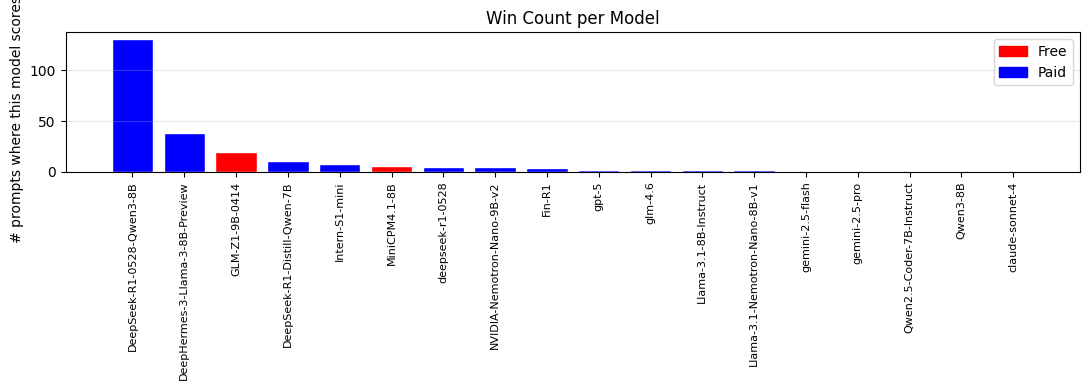

Saved eda_best_per_prompt.png


In [151]:
pivot_wins = df.pivot_table(index='prompt_id', columns='model', values='score', aggfunc='mean')
best_per_prompt = pivot_wins.idxmax(axis=1)
counts = best_per_prompt.value_counts()

print(f'{len(counts)} different models each win on at least one prompt')
print(f'Top model ({counts.index[0]}) wins on {counts.iloc[0]} / {pivot_wins.shape[0]} prompts ({100*counts.iloc[0]/pivot_wins.shape[0]:.1f}%)')

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(11, 4))
bar_colors = ['red' if m in free_list else 'blue' for m in counts.index]
ax.bar(range(len(counts)), counts.values, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=90, fontsize=8)
ax.set_ylabel('# prompts where this model scores best')
ax.set_title('Win Count per Model')
ax.legend(handles=[Patch(color='red', label='Free'), Patch(color='blue', label='Paid')])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_best_per_prompt.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_best_per_prompt.png')

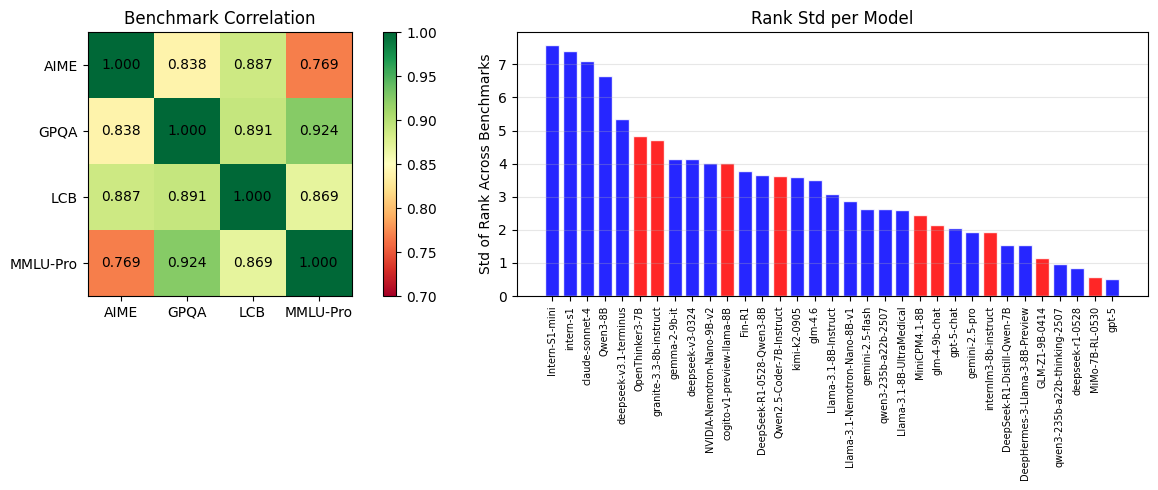

Saved eda_benchmark_correlation.png
Cross-benchmark correlations range: 0.769 – 0.924  (avg 0.863)

dataset    AIME   GPQA    LCB  MMLU-Pro
dataset                                
AIME      1.000  0.838  0.887     0.769
GPQA      0.838  1.000  0.891     0.924
LCB       0.887  0.891  1.000     0.869
MMLU-Pro  0.769  0.924  0.869     1.000


In [152]:
pivot_bm = df.pivot_table(index='model', columns='dataset', values='score', aggfunc='mean')
corr_mat = pivot_bm.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(corr_mat.values, cmap='RdYlGn', vmin=0.7, vmax=1.0)
ax.set_xticks(range(len(corr_mat.columns))); ax.set_xticklabels(corr_mat.columns)
ax.set_yticks(range(len(corr_mat.index)));  ax.set_yticklabels(corr_mat.index)
for i in range(len(corr_mat)):
    for j in range(len(corr_mat)):
        ax.text(j, i, f'{corr_mat.values[i,j]:.3f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)
ax.set_title('Benchmark Correlation')

ax = axes[1]
rank_std = pivot_bm.rank(ascending=False).std(axis=1).sort_values(ascending=False)
bar_c = ['red' if m in free_list else 'blue' for m in rank_std.index]
ax.bar(range(len(rank_std)), rank_std.values, color=bar_c, edgecolor='white', alpha=0.85)
ax.set_xticks(range(len(rank_std)))
ax.set_xticklabels(rank_std.index, rotation=90, fontsize=7)
ax.set_ylabel('Std of Rank Across Benchmarks')
ax.set_title('Rank Std per Model')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_benchmark_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_benchmark_correlation.png')

import numpy as np
off_diag = corr_mat.values[np.triu_indices(len(corr_mat), k=1)]
print(f'Cross-benchmark correlations range: {off_diag.min():.3f} – {off_diag.max():.3f}  (avg {off_diag.mean():.3f})')
print()
print(corr_mat.round(3).to_string())

# Baseline Pyomo Routing Model

In [153]:
def solve_weighted_sum_router(df: pd.DataFrame, alpha: float, prompt_weights: dict):
    """
    Decision Variables:
        x[p,m] in {0,1}: whether prompt p is assigned to model m

    Solve:
        minimize sum_p w_p sum_m x[p,m] * cost[p,m]
                 - alpha * sum_p w_p sum_m x[p,m] * score[p,m]

    s.t.
        for each prompt p: sum_m x[p,m] = 1
        x[p,m] in {0,1}

    where:
        alpha: the weight to balance the two conflicting objectives;
        prompt_weights: w_p for each prompt for approximating the expected  stochastic objective

    Interpretation:
        Choose for each prompt the best model among all possible candidate models. The result shall be interpreted as the "oracle" routing policy that you generally do not hope to beat.

        Your model should be much more complex and incorporate multiple realistic constraints to better reflect business and research considerations.
    """
    prompts, models, datasets, score, cost, dataset_of_prompt = make_parameter_dicts(df)

    # Restrict feasible assignments to those present in data
    available_pairs = sorted(score.keys())

    model = pyo.ConcreteModel()

    model.P = pyo.Set(initialize=prompts)
    model.M = pyo.Set(initialize=models)
    model.PM = pyo.Set(initialize=available_pairs, dimen=2)

    model.w = pyo.Param(model.P, initialize=prompt_weights, within=pyo.NonNegativeReals)
    model.score = pyo.Param(model.PM, initialize=score, within=pyo.Reals)
    model.cost = pyo.Param(model.PM, initialize=cost, within=pyo.NonNegativeReals)

    model.x = pyo.Var(model.PM, within=pyo.Binary)

    def assignment_rule(mdl, p):
        feasible_models = [mm for (pp, mm) in mdl.PM if pp == p]
        return sum(mdl.x[p, mm] for mm in feasible_models) == 1

    model.assignment = pyo.Constraint(model.P, rule=assignment_rule)

    def objective_rule(mdl):
        avg_cost = sum(mdl.w[p] * mdl.cost[p, m] * mdl.x[p, m] for (p, m) in mdl.PM)
        avg_score = sum(mdl.w[p] * mdl.score[p, m] * mdl.x[p, m] for (p, m) in mdl.PM)
        return avg_cost - alpha * avg_score

    model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    solver = choose_solver()
    results = solver.solve(model, tee=False)

    # Extract chosen routes
    chosen_rows = []
    for (p, m) in model.PM:
        if pyo.value(model.x[p, m]) > 0.5:
            chosen_rows.append({
                "prompt_id": p,
                "model": m,
                "dataset": dataset_of_prompt[p],
                "weight": prompt_weights[p],
                "score": score[(p, m)],
                "cost": cost[(p, m)],
            })

    chosen_df = pd.DataFrame(chosen_rows).sort_values(["dataset", "prompt_id"]).reset_index(drop=True)

    avg_cost = float((chosen_df["weight"] * chosen_df["cost"]).sum())
    avg_score = float((chosen_df["weight"] * chosen_df["score"]).sum())
    objective_value = avg_cost - alpha * avg_score

    return {
        "alpha": alpha,
        "policy_name": "Oracle Routing",
        "avg_cost": avg_cost,
        "avg_score": avg_score,
        "objective_value": objective_value,
        "assignments": chosen_df,
        "solver_status": str(results.solver.status),
        "termination_condition": str(results.solver.termination_condition),
    }

In [154]:
# ============================================================
# Additional baseline policies

# These reflects the most naive policies that your optimal solution should  outperform.
# ============================================================

def evaluate_single_best(df: pd.DataFrame, alpha: float, prompt_weights: dict):
    """
    Choose one model for all prompts using the same decision metric {Cost - alph * Score}.
    """
    prompts, models, datasets, score, cost, dataset_of_prompt = make_parameter_dicts(df)

    rows = []
    for m in models:
        sub = df[df["model"] == m].copy()

        # Need coverage for every prompt
        covered_prompts = set(sub["prompt_id"])
        if covered_prompts != set(prompts):
            continue

        weighted_cost = 0.0
        weighted_score = 0.0
        for _, r in sub.iterrows():
            p = r["prompt_id"]
            weighted_cost += prompt_weights[p] * float(r["cost"])
            weighted_score += prompt_weights[p] * float(r["score"])

        obj = weighted_cost - alpha * weighted_score
        rows.append({
            "alpha": alpha,
            "model": m,
            "avg_cost": weighted_cost,
            "avg_score": weighted_score,
            "objective_value": obj,
        })

    if not rows:
        raise RuntimeError("No model covers all prompts for the Single Best baseline.")

    cand = pd.DataFrame(rows).sort_values("objective_value").reset_index(drop=True)
    best_model = cand.loc[0, "model"]
    best_cost = float(cand.loc[0, "avg_cost"])
    best_score = float(cand.loc[0, "avg_score"])
    best_obj = float(cand.loc[0, "objective_value"])

    assignment_df = df[df["model"] == best_model][["prompt_id", "dataset", "model", "score", "cost"]].copy()
    assignment_df["weight"] = assignment_df["prompt_id"].map(prompt_weights)

    return {
        "alpha": alpha,
        "policy_name": "Single Best",
        "selected_model": best_model,
        "avg_cost": best_cost,
        "avg_score": best_score,
        "objective_value": best_obj,
        "assignments": assignment_df.sort_values(["dataset", "prompt_id"]).reset_index(drop=True),
    }

def evaluate_single_best_per_benchmark(df: pd.DataFrame, alpha: float, prompt_weights: dict):
    """
    For each benchmark dataset, choose one model used for all prompts in that dataset.
    """
    prompts, models, datasets, score, cost, dataset_of_prompt = make_parameter_dicts(df)

    selected_models = {}
    assignment_rows = []

    for d in datasets:
        df_d = df[df["dataset"] == d].copy()
        prompts_d = sorted(df_d["prompt_id"].unique().tolist())

        rows = []
        for m in models:
            sub = df_d[df_d["model"] == m].copy()

            if set(sub["prompt_id"]) != set(prompts_d):
                continue

            weighted_cost = 0.0
            weighted_score = 0.0
            for _, r in sub.iterrows():
                p = r["prompt_id"]
                weighted_cost += prompt_weights[p] * float(r["cost"])
                weighted_score += prompt_weights[p] * float(r["score"])

            obj = weighted_cost - alpha * weighted_score
            rows.append({
                "dataset": d,
                "model": m,
                "avg_cost_dataset_contrib": weighted_cost,
                "avg_score_dataset_contrib": weighted_score,
                "objective_value_dataset_contrib": obj,
            })

        if not rows:
            raise RuntimeError(f"No model covers all prompts in dataset {d}.")

        cand = pd.DataFrame(rows).sort_values("objective_value_dataset_contrib").reset_index(drop=True)
        best_model = cand.loc[0, "model"]
        selected_models[d] = best_model

        chosen = df_d[df_d["model"] == best_model][["prompt_id", "dataset", "model", "score", "cost"]].copy()
        chosen["weight"] = chosen["prompt_id"].map(prompt_weights)
        assignment_rows.append(chosen)

    assignment_df = pd.concat(assignment_rows, ignore_index=True)
    avg_cost = float((assignment_df["weight"] * assignment_df["cost"]).sum())
    avg_score = float((assignment_df["weight"] * assignment_df["score"]).sum())
    obj = avg_cost - alpha * avg_score

    return {
        "alpha": alpha,
        "policy_name": "Single Best per Benchmark",
        "selected_models_by_dataset": selected_models,
        "avg_cost": avg_cost,
        "avg_score": avg_score,
        "objective_value": obj,
        "assignments": assignment_df.sort_values(["dataset", "prompt_id"]).reset_index(drop=True),
    }


# Plotting Functionality

In [155]:
def plot_frontier(results_df: pd.DataFrame, output_path: Path):
    """
    Scatter/line plot on the cost-performance plane.
    x-axis: average cost (weighted by prompt-weights)
    y-axis: average score (weighted by prompt-weights)
    """
    plt.figure(figsize=(10, 7))

    # Oracle weighted-sum routing frontier
    opt = results_df[results_df["policy_name"] == "Oracle Routing"].sort_values("alpha")
    plt.plot(opt["avg_cost"], opt["avg_score"], marker="o", linewidth=2, label="Oracle Routing")

    # Single Best baseline
    sb = results_df[results_df["policy_name"] == "Single Best"].sort_values("alpha")
    plt.plot(sb["avg_cost"], sb["avg_score"], marker="s", linestyle="--", linewidth=1.5, label="Single Best")

    # Single Best per Benchmark baseline
    sbb = results_df[results_df["policy_name"] == "Single Best per Benchmark"].sort_values("alpha")
    plt.plot(
        sbb["avg_cost"], sbb["avg_score"],
        marker="^", linestyle="--", linewidth=1.5,
        label="Single Best per Benchmark"
    )

    # Two-Stage router at various pool sizes
    two_stage_styles = {
        'Two-Stage K=3':  'dodgerblue',
        'Two-Stage K=6':  'darkorange',
        'Two-Stage K=10': 'forestgreen',
    }
    for pname, color in two_stage_styles.items():
        sub = results_df[results_df["policy_name"] == pname].sort_values("avg_cost")
        if not sub.empty:
            plt.plot(sub["avg_cost"], sub["avg_score"],
                     marker="D", linestyle="-", linewidth=2.0, color=color, label=pname)

    plt.xlabel("Weighted Average Cost")
    plt.ylabel("Weighted Average Performance (Score)")
    plt.title("Routing Policies on the Cost-Performance Plane")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()
    plt.close()

# My Implementation

In [156]:
def solve_two_stage_router(df, alpha, prompt_weights, K=None, budget=None, min_free=1, q_min=None, policy_name=None):
    """
    Two-Stage Stochastic LLM Router (SAA).

    Stage 1: y_m in {0,1}  — select model pool
    Stage 2: x_pm in {0,1} — route prompt p to model m

    min  sum_pm w_p * C(p,m) * x_pm  -  alpha * sum_pm w_p * Q(p,m) * x_pm
    s.t.
      sum_m x_pm = 1 for all p   [assignment]
      x_pm <= y_m  for all pm  [linking / stage coupling]
      sum_m y_m <= K [pool size]
      sum_pm w_p*C(p,m)*x_pm <= B [budget]
      sum_{m in M0} y_m >= min_free [free-model inclusion]
      sum_pm w_p*Q(p,m)*x_pm >= q_min [quality floor]
      y_m, x_pm in {0,1}
    """
    prompts, models, datasets, score, cost, dataset_of_prompt = make_parameter_dicts(df)
    pairs = sorted(score.keys())

    # Precompute feasible models per prompt for fast constraint building
    p2m = {}
    for p in prompts:
        p2m[p] = []
    for (p, m) in pairs:
        p2m[p].append(m)

    # Identify free models
    model_max_cost = {}
    for (p, m), c in cost.items():
        model_max_cost[m] = max(model_max_cost.get(m, 0.0), c)
    free_models = [m for m, mc in model_max_cost.items() if mc == 0.0]

    mdl = pyo.ConcreteModel()
    mdl.P  = pyo.Set(initialize=prompts)
    mdl.M  = pyo.Set(initialize=models)
    mdl.PM = pyo.Set(initialize=pairs, dimen=2)

    mdl.w     = pyo.Param(mdl.P,  initialize=prompt_weights, within=pyo.NonNegativeReals)
    mdl.score = pyo.Param(mdl.PM, initialize=score, within=pyo.Reals)
    mdl.cost  = pyo.Param(mdl.PM, initialize=cost,  within=pyo.NonNegativeReals)

    mdl.y = pyo.Var(mdl.M,  within=pyo.Binary)   # Stage 1: pool selection
    mdl.x = pyo.Var(mdl.PM, within=pyo.Binary)   # Stage 2: routing

    # C1
    def c1(mdl, p):
        return sum(mdl.x[p, m] for m in p2m[p]) == 1
    mdl.c1 = pyo.Constraint(mdl.P, rule=c1)

    # C2
    def c2(mdl, p, m):
        return mdl.x[p, m] <= mdl.y[m]
    mdl.c2 = pyo.Constraint(mdl.PM, rule=c2)

    # C3: Pool size limit
    if K is not None:
        mdl.c3 = pyo.Constraint(expr=sum(mdl.y[m] for m in mdl.M) <= K)

    # C4: Weighted average cost budget
    if budget is not None:
        mdl.c4 = pyo.Constraint(
            expr=sum(mdl.w[p] * mdl.cost[p, m] * mdl.x[p, m]
                     for (p, m) in pairs) <= budget)

    # C5: At least min_free zero-cost models in pool
    if min_free > 0 and len(free_models) >= min_free:
        mdl.c5 = pyo.Constraint(
            expr=sum(mdl.y[m] for m in free_models) >= min_free)

    # C6: Minimum quality floor on weighted average score
    if q_min is not None:
        mdl.c6 = pyo.Constraint(
            expr=sum(mdl.w[p] * mdl.score[p, m] * mdl.x[p, m]
                     for (p, m) in pairs) >= q_min)

    # Objective: minimize weighted avg cost - alpha * weighted avg score
    mdl.obj = pyo.Objective(
        expr = (sum(mdl.w[p] * mdl.cost[p, m] * mdl.x[p, m] for (p, m) in pairs) - alpha * sum(mdl.w[p] * mdl.score[p, m] * mdl.x[p, m] for (p, m) in pairs)), sense = pyo.minimize)

    res = choose_solver().solve(mdl)

    selected = sorted(m for m in models if pyo.value(mdl.y[m]) > 0.5)
    rows = []
    for (p, m) in pairs:
        if pyo.value(mdl.x[p, m]) > 0.5:
            rows.append({'prompt_id': p, 'model': m, 'dataset': dataset_of_prompt[p],
                         'weight': prompt_weights[p],
                         'score': score[(p, m)], 'cost': cost[(p, m)]})
    ch = pd.DataFrame(rows).sort_values(['dataset', 'prompt_id']).reset_index(drop=True)
    avg_cost  = float((ch['weight'] * ch['cost']).sum())
    avg_score = float((ch['weight'] * ch['score']).sum())

    if policy_name is None:
        parts = ['Two-Stage']
        if K is not None:      parts.append(f'K={K}')
        if budget is not None: parts.append(f'B={budget:.4f}')
        if q_min is not None:  parts.append(f'q>={q_min:.2f}')
        policy_name = ' '.join(parts)

    return {
        'alpha': alpha, 'K': K, 'budget': budget, 'q_min': q_min,
        'policy_name': policy_name,
        'selected_models': selected,
        'n_models': len(selected),
        'avg_cost': avg_cost, 'avg_score': avg_score,
        'objective_value': avg_cost - alpha * avg_score,
        'assignments': ch,
        'solver_status': str(res.solver.status),
    }

# RQ1: How does performance degrade as you shrink K?

In [157]:
uniform_w = build_prompt_weights(df)

oracle_ref   = solve_weighted_sum_router(df, ALPHA_FIXED, uniform_w)
oracle_obj   = oracle_ref['objective_value']
oracle_score = oracle_ref['avg_score']
print(f'Oracle (K=33): score={oracle_score:.4f}, cost={oracle_ref["avg_cost"]:.6f}')
print()

q1_records = []
for K in K_GRID:
    print(f'  K={K}...', end=' ', flush=True)
    res = solve_two_stage_router(df, ALPHA_FIXED, uniform_w, K=K, min_free=0)
    gap = res['objective_value'] - oracle_obj
    pct = 100.0 * res['avg_score'] / oracle_score if oracle_score > 0 else 0.0
    q1_records.append({
        'K': K,
        'avg_score': res['avg_score'],
        'avg_cost':  res['avg_cost'],
        'objective_value': res['objective_value'],
        'gap_from_oracle': gap,
        'pct_oracle_score': pct,
        'selected_models': '; '.join(res['selected_models']),
    })
    print(f'score={res["avg_score"]:.4f} ({pct:.1f}% of oracle), '
          f'cost={res["avg_cost"]:.6f}, gap={gap:.6f}')

q1_df = pd.DataFrame(q1_records)
print()
print('Q1 Summary:')
print(q1_df[['K', 'avg_score', 'pct_oracle_score', 'avg_cost', 'gap_from_oracle']].to_string(index=False))

Using solver: appsi_highs
Oracle (K=33): score=0.9833, cost=0.001681

  K=1... Using solver: appsi_highs
score=0.8875 (90.3% of oracle), cost=0.042548, gap=0.136700
  K=2... Using solver: appsi_highs
score=0.9375 (95.3% of oracle), cost=0.017104, gap=0.061256
  K=3... Using solver: appsi_highs
score=0.9583 (97.5% of oracle), cost=0.012480, gap=0.035798
  K=4... Using solver: appsi_highs
score=0.9708 (98.7% of oracle), cost=0.011973, gap=0.022792
  K=5... Using solver: appsi_highs
score=0.9792 (99.6% of oracle), cost=0.007737, gap=0.010223
  K=6... Using solver: appsi_highs
score=0.9833 (100.0% of oracle), cost=0.007413, gap=0.005732
  K=7... Using solver: appsi_highs
score=0.9833 (100.0% of oracle), cost=0.004520, gap=0.002838
  K=8... Using solver: appsi_highs
score=0.9833 (100.0% of oracle), cost=0.003234, gap=0.001552
  K=9... Using solver: appsi_highs
score=0.9833 (100.0% of oracle), cost=0.002635, gap=0.000954
  K=10... Using solver: appsi_highs
score=0.9833 (100.0% of oracle), co

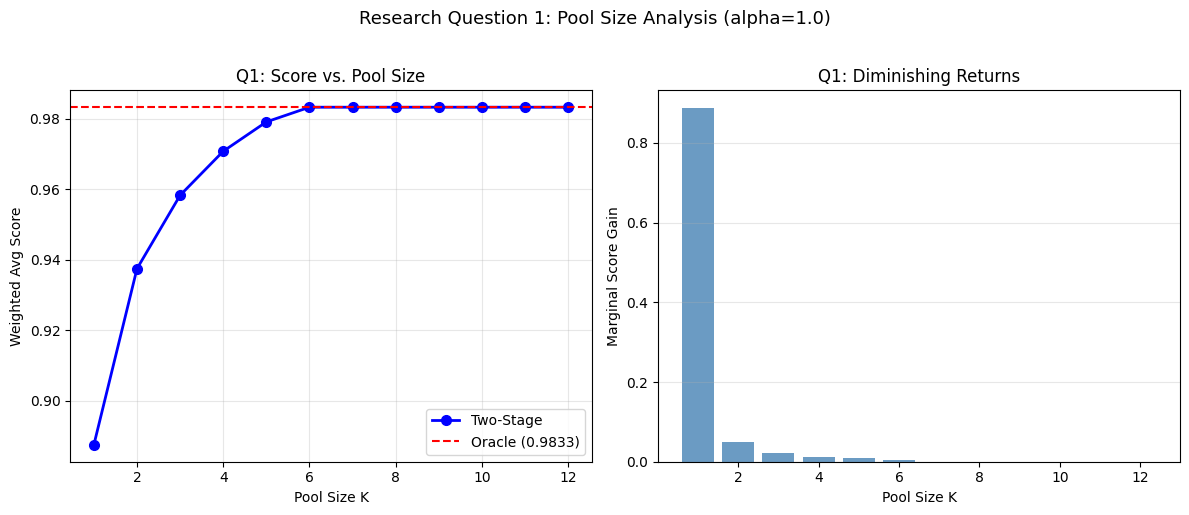

Saved q1_pool_size.png


In [158]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(q1_df['K'], q1_df['avg_score'], 'bo-', lw=2, markersize=7, label='Two-Stage')
ax.axhline(oracle_score, color='red', lw=1.5, ls='--', label=f'Oracle ({oracle_score:.4f})')
ax.set_xlabel('Pool Size K')
ax.set_ylabel('Weighted Avg Score')
ax.set_title('Q1: Score vs. Pool Size')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
marginal = q1_df['avg_score'].diff().fillna(q1_df['avg_score'].iloc[0])
bars = ax.bar(q1_df['K'], marginal, color='steelblue', alpha=0.8)
ax.set_xlabel('Pool Size K')
ax.set_ylabel('Marginal Score Gain')
ax.set_title('Q1: Diminishing Returns')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Research Question 1: Pool Size Analysis (alpha=1.0)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'q1_pool_size.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved q1_pool_size.png')

# RQ 2: What models are selected in the optimal pool? Do conclusions differ across benchmark domains?

In [159]:
K_FIXED = 6
q2_records = []

for scheme_name, focus_ds in WEIGHT_SCHEMES.items():
    print(f'  Scheme: {scheme_name}')
    w = build_prompt_weights(df, focus_datasets=focus_ds, boost=3.0)
    for a in ALPHA_GRID:
        res = solve_two_stage_router(df, a, w, K=K_FIXED, min_free=0)
        q2_records.append({
            'scheme':     scheme_name,
            'alpha':      a,
            'avg_cost':   res['avg_cost'],
            'avg_score':  res['avg_score'],
            'n_models':   res['n_models'],
            'selected':   '; '.join(res['selected_models']),
        })
    print(f'    done. avg score range: '
          f'{min(r["avg_score"] for r in q2_records if r["scheme"]==scheme_name):.4f}'
          f' - {max(r["avg_score"] for r in q2_records if r["scheme"]==scheme_name):.4f}')

q2_df = pd.DataFrame(q2_records)
print()
print('Q2 Mean scores by scheme:')
print(q2_df.groupby('scheme')['avg_score'].mean().sort_values(ascending=False))

  Scheme: Uniform
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
    done. avg score range: 0.9375 - 0.9833
  Scheme: Coding-Heavy
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
    done. avg score range: 0.9417 - 0.9889
  Scheme: Math-Heavy
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
    done. avg score range: 0.9250 - 0.9778
  Scheme: Knowledge-Heavy
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Usi

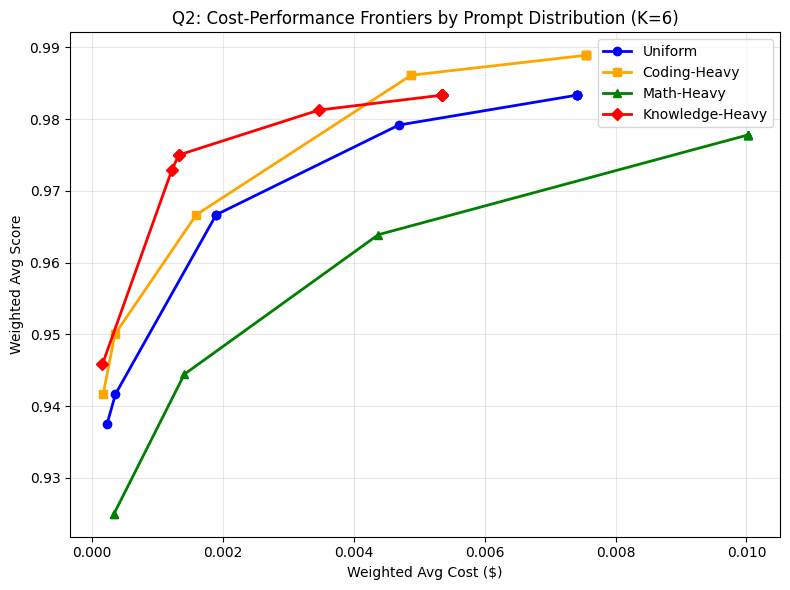

Saved q2_distribution_robustness.png

Selected models at alpha=1.0 per scheme:
  Uniform             : GLM-Z1-9B-0414; Llama-3.1-8B-UltraMedical; gemini-2.5-flash; glm-4.6; gpt-5; kimi-k2-0905
  Coding-Heavy        : GLM-Z1-9B-0414; Llama-3.1-8B-UltraMedical; gemini-2.5-flash; glm-4.6; gpt-5; kimi-k2-0905
  Math-Heavy          : GLM-Z1-9B-0414; Llama-3.1-8B-UltraMedical; gemini-2.5-flash; glm-4.6; gpt-5; kimi-k2-0905
  Knowledge-Heavy     : GLM-Z1-9B-0414; Llama-3.1-8B-UltraMedical; gemini-2.5-flash; glm-4.6; gpt-5; kimi-k2-0905


In [160]:
colors  = ['blue', 'orange', 'green', 'red']
markers = ['o', 's', '^', 'D']
schemes = list(WEIGHT_SCHEMES.keys())

fig, ax = plt.subplots(figsize=(8, 6))

for i, scheme in enumerate(schemes):
    sub = q2_df[q2_df['scheme'] == scheme].sort_values('avg_cost')
    ax.plot(sub['avg_cost'], sub['avg_score'],
            color=colors[i], marker=markers[i], lw=2, label=scheme)
ax.set_xlabel('Weighted Avg Cost ($)')
ax.set_ylabel('Weighted Avg Score')
ax.set_title('Q2: Cost-Performance Frontiers by Prompt Distribution (K=6)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'q2_distribution_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved q2_distribution_robustness.png')

print()
print('Selected models at alpha=1.0 per scheme:')
alpha1_df = q2_df[q2_df['alpha'] == ALPHA_FIXED].copy()
for _, row in alpha1_df.iterrows():
    print(f'  {row["scheme"]:20s}: {row["selected"]}')

# Ablation

=== Constraint Ablation Study (alpha=1.0, uniform weights) ===
  No extra constraints (K=33)... Using solver: appsi_highs
score=0.9833, cost=0.001681, n_models=33
  +C3: Pool size K=6... Using solver: appsi_highs
score=0.9833, cost=0.007413, n_models=6
  +C4: Budget B=0.005... Using solver: appsi_highs
score=0.9792, cost=0.004690, n_models=6
  +C5: Min 1 free model... Using solver: appsi_highs
score=0.9833, cost=0.007414, n_models=6
  +C6: Quality floor q>=0.68... Using solver: appsi_highs
score=0.9833, cost=0.007414, n_models=6
  Full model (C3+C4+C5)... Using solver: appsi_highs
score=0.9792, cost=0.004690, n_models=6

                     config  avg_score  avg_cost  n_models
No extra constraints (K=33)   0.983333  0.001681        33
         +C3: Pool size K=6   0.983333  0.007413         6
        +C4: Budget B=0.005   0.979167  0.004690         6
      +C5: Min 1 free model   0.983333  0.007414         6
 +C6: Quality floor q>=0.68   0.983333  0.007414         6
      Full model 

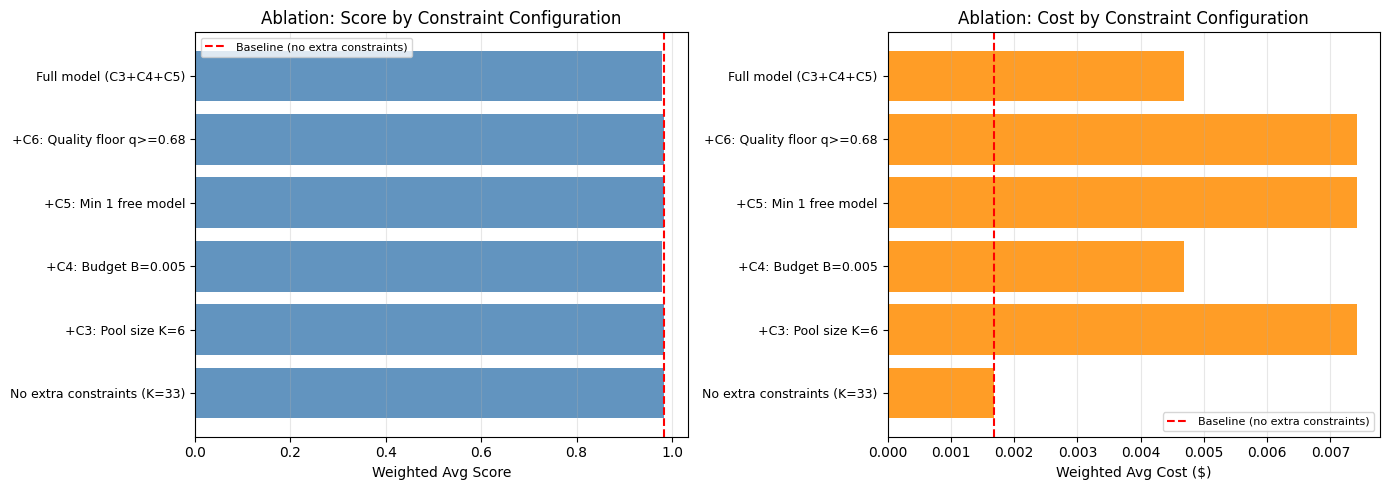

Saved ablation_constraints.png


In [ ]:
print('=== Constraint Ablation Study (alpha=1.0, uniform weights) ===')
uniform_w = build_prompt_weights(df)

ablation_configs = [
    {'name': 'No extra constraints (K=33)',  'K': 33,  'budget': None,  'min_free': 0, 'q_min': None},
    {'name': '+C3: Pool size K=6',          'K': 6,   'budget': None,  'min_free': 0, 'q_min': None},
    {'name': '+C4: Budget B=0.005',         'K': 6,   'budget': 0.005, 'min_free': 0, 'q_min': None},
    {'name': '+C5: Min 1 free model',       'K': 6,   'budget': None,  'min_free': 1, 'q_min': None},
    {'name': '+C6: Quality floor q>=0.68',  'K': 6,   'budget': None,  'min_free': 0, 'q_min': 0.68},
    {'name': 'Full model (C3+C4+C5)',       'K': 6,   'budget': 0.005, 'min_free': 1, 'q_min': None},
]

abl_records = []
for cfg in ablation_configs:
    print(f'  {cfg["name"]}...', end=' ', flush=True)
    res = solve_two_stage_router(df, ALPHA_FIXED, uniform_w,
                                 K=cfg['K'], budget=cfg['budget'],
                                 min_free=cfg['min_free'], q_min=cfg['q_min'],
                                 policy_name=cfg['name'])
    abl_records.append({
        'config': cfg['name'],
        'avg_score': res['avg_score'],
        'avg_cost':  res['avg_cost'],
        'n_models':  res['n_models'],
    })
    print(f'score={res["avg_score"]:.4f}, cost={res["avg_cost"]:.6f}, n_models={res["n_models"]}')

abl_df = pd.DataFrame(abl_records)
print()
print(abl_df[['config', 'avg_score', 'avg_cost', 'n_models']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(abl_df))
baseline_score = abl_df['avg_score'].iloc[0]
baseline_cost  = abl_df['avg_cost'].iloc[0]

axes[0].barh(list(x), abl_df['avg_score'], color='steelblue', alpha=0.85)
axes[0].set_yticks(list(x)); axes[0].set_yticklabels(abl_df['config'], fontsize=9)
axes[0].set_xlabel('Weighted Avg Score')
axes[0].set_title('Ablation: Score by Constraint Configuration')
axes[0].axvline(baseline_score, color='red', lw=1.5, ls='--', label='Baseline (no extra constraints)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(list(x), abl_df['avg_cost'], color='darkorange', alpha=0.85)
axes[1].set_yticks(list(x)); axes[1].set_yticklabels(abl_df['config'], fontsize=9)
axes[1].set_xlabel('Weighted Avg Cost ($)')
axes[1].set_title('Ablation: Cost by Constraint Configuration')
axes[1].axvline(baseline_cost, color='red', lw=1.5, ls='--', label='Baseline (no extra constraints)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ablation_constraints.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ablation_constraints.png')

In [166]:
print('=== Budget Sensitivity Analysis (K=6, alpha=1.0) ===')
uniform_w = build_prompt_weights(df)
budget_records = []

for B in BUDGET_GRID:
    print(f'  B={B:.4f}...', end=' ', flush=True)
    try:
        res = solve_two_stage_router(df, ALPHA_FIXED, uniform_w, K=6, budget=B, min_free=0)
        budget_records.append({
            'budget': B, 'avg_cost': res['avg_cost'], 'avg_score': res['avg_score'],
            'n_models': res['n_models'], 'feasible': True,
        })
        print(f'score={res["avg_score"]:.4f}, actual_cost={res["avg_cost"]:.6f}')
    except Exception as e:
        print(f'INFEASIBLE ({e})')
        budget_records.append({'budget': B, 'feasible': False})

budget_df = pd.DataFrame(budget_records)
bdf = budget_df[budget_df['feasible']].copy()

=== Budget Sensitivity Analysis (K=6, alpha=1.0) ===
  B=0.0005... Using solver: appsi_highs
score=0.9417, actual_cost=0.000361
  B=0.0010... Using solver: appsi_highs
score=0.9458, actual_cost=0.000797
  B=0.0020... Using solver: appsi_highs
score=0.9667, actual_cost=0.001899
  B=0.0050... Using solver: appsi_highs
score=0.9792, actual_cost=0.004690
  B=0.0100... Using solver: appsi_highs
score=0.9833, actual_cost=0.007413
  B=0.0200... Using solver: appsi_highs
score=0.9833, actual_cost=0.007413
  B=0.0500... Using solver: appsi_highs
score=0.9833, actual_cost=0.007413


In [167]:
print('=== Quality Threshold Sensitivity (K=6, alpha=1.0) ===')
uniform_w = build_prompt_weights(df)
Q_MIN_GRID = [0.50, 0.55, 0.60, 0.65, 0.68, 0.70, 0.72, 0.74]
qt_records = []

for Q in Q_MIN_GRID:
    print(f'  q_min={Q:.2f}...', end=' ', flush=True)
    try:
        res = solve_two_stage_router(df, ALPHA_FIXED, uniform_w, K=6, q_min=Q, min_free=0)
        qt_records.append({
            'q_min': Q, 'avg_cost': res['avg_cost'], 'avg_score': res['avg_score'],
            'n_models': res['n_models'], 'feasible': True,
        })
        print(f'score={res["avg_score"]:.4f}, cost={res["avg_cost"]:.6f}')
    except Exception:
        print('INFEASIBLE')
        qt_records.append({'q_min': Q, 'feasible': False})

qt_df = pd.DataFrame(qt_records)
qdf = qt_df[qt_df['feasible']].copy()

=== Quality Threshold Sensitivity (K=6, alpha=1.0) ===
  q_min=0.50... Using solver: appsi_highs
score=0.9833, cost=0.007414
  q_min=0.55... Using solver: appsi_highs
score=0.9833, cost=0.007414
  q_min=0.60... Using solver: appsi_highs
score=0.9833, cost=0.007414
  q_min=0.65... Using solver: appsi_highs
score=0.9833, cost=0.007414
  q_min=0.68... Using solver: appsi_highs
score=0.9833, cost=0.007414
  q_min=0.70... Using solver: appsi_highs
score=0.9833, cost=0.007414
  q_min=0.72... Using solver: appsi_highs
score=0.9833, cost=0.007414
  q_min=0.74... Using solver: appsi_highs
score=0.9833, cost=0.007414


=== Main Frontier: All Policies (uniform weights) ===
  alpha=0.01 ... Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
done
  alpha=0.05 ... Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
done
  alpha=0.1 ... Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
done
  alpha=0.2 ... Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
done
  alpha=0.5 ... Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
done
  alpha=1.0 ... Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
done
  alpha=2.0 ... Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
Using solver: appsi_highs
done
  alpha=5.0 ... Using solver: appsi_highs
Using solver: appsi_highs
U

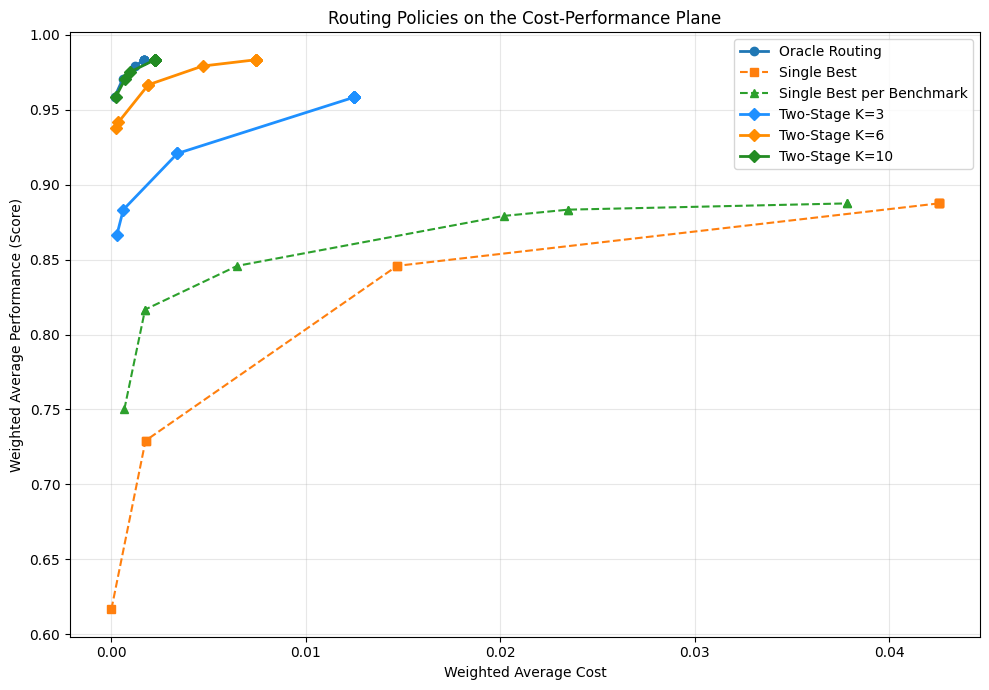

Saved cost_performance_frontier.png

Summary at alpha=1.0:
              policy_name  avg_score  avg_cost
           Oracle Routing   0.983333  0.001681
            Two-Stage K=6   0.983333  0.007413
           Two-Stage K=10   0.983333  0.002235
            Two-Stage K=3   0.958333  0.012480
              Single Best   0.887500  0.042548
Single Best per Benchmark   0.883333  0.023497


In [168]:
print('=== Main Frontier: All Policies (uniform weights) ===')
uniform_w = build_prompt_weights(df)
all_records = []

for a in ALPHA_GRID:
    print(f'  alpha={a}', end=' ... ', flush=True)

    res = solve_weighted_sum_router(df, a, uniform_w)
    all_records.append({'alpha': a, 'policy_name': res['policy_name'],
                        'avg_cost': res['avg_cost'], 'avg_score': res['avg_score']})

    res = evaluate_single_best(df, a, uniform_w)
    all_records.append({'alpha': a, 'policy_name': res['policy_name'],
                        'avg_cost': res['avg_cost'], 'avg_score': res['avg_score']})

    res = evaluate_single_best_per_benchmark(df, a, uniform_w)
    all_records.append({'alpha': a, 'policy_name': res['policy_name'],
                        'avg_cost': res['avg_cost'], 'avg_score': res['avg_score']})

    for K in [3, 6, 10]:
        res = solve_two_stage_router(df, a, uniform_w, K=K, min_free=0,
                                     policy_name=f'Two-Stage K={K}')
        all_records.append({'alpha': a, 'policy_name': res['policy_name'],
                            'avg_cost': res['avg_cost'], 'avg_score': res['avg_score']})
    print('done')

frontier_df = pd.DataFrame(all_records)
frontier_df.to_csv(OUTPUT_DIR / 'policy_summary.csv', index=False)

plot_frontier(frontier_df, OUTPUT_DIR / 'cost_performance_frontier.png')
print('Saved cost_performance_frontier.png')

print()
print('Summary at alpha=1.0:')
at1 = frontier_df[frontier_df['alpha'] == 1.0].sort_values('avg_score', ascending=False)
print(at1[['policy_name', 'avg_score', 'avg_cost']].to_string(index=False))